# Análisis de Ventas Minoristas con Pandas, Matplotlib y Seaborn

## Objetivo

Analizar el conjunto de datos superstore utilizando visualizaciones univariantes, bivariantes y multivariantes para identificar patrones en ventas, beneficios y otras variables relevantes.

### 2. Importar librerías

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Mostrar gráficos dentro del notebook
%matplotlib inline

### 3. Cargar el dataset

In [22]:
df = pd.read_csv("superstore_dataset2012.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,1/2/2012,7/2/2012,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,1/2/2012,6/2/2012,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High
3,2828,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,FUR-CH-10001423,Furniture,Chairs,"Harbour Creations Rocking Chair, Black",192.8800,2,0.00,54.0000,19.27,High
4,6762,MX-2012-151904,1/2/2012,3/2/2012,First Class,DJ-13420,Denny Joy,Corporate,Villa Canales,Guatemala,...,OFF-PA-10003571,Office Supplies,Paper,"Enermax Cards & Envelopes, Recycled",94.0200,3,0.00,1.8600,10.73,Medium


### 4. Exploración inicial

In [23]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nInformación general:")
df.info()

print("\nValores nulos:")
display(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())

Dimensiones del dataset:
(4246, 24)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 4246 entries, 0 to 4245
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          4246 non-null   int64  
 1   Order ID        4246 non-null   str    
 2   Order Date      4246 non-null   str    
 3   Ship Date       4246 non-null   str    
 4   Ship Mode       4246 non-null   str    
 5   Customer ID     4246 non-null   str    
 6   Customer Name   4246 non-null   str    
 7   Segment         4246 non-null   str    
 8   City            4246 non-null   str    
 9   State           4246 non-null   str    
 10  Country         4246 non-null   str    
 11  Postal Code     823 non-null    float64
 12  Market          4246 non-null   str    
 13  Region          4246 non-null   str    
 14  Product ID      4246 non-null   str    
 15  Category        4246 non-null   str    
 16  Sub-Category    4246 non-null  

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Customer Name        0
Segment              0
City                 0
State                0
Country              0
Postal Code       3423
Market               0
Region               0
Product ID           0
Category             0
Sub-Category         0
Product Name         0
Sales                0
Quantity             0
Discount             0
Profit               0
Shipping Cost        0
Order Priority       0
dtype: int64


Estadísticas descriptivas:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,4246.000000,823.000000,4246.000000,4246.000000,4246.000000,4246.000000,4246.000000
mean,25248.240226,48442.910085,237.029481,3.444183,0.146615,27.698282,24.539708
std,14711.393243,32118.342697,426.974969,2.228431,0.216120,147.459878,50.422150
min,66.000000,1040.000000,1.112000,1.000000,0.000000,-1806.240000,0.030000
25%,12424.250000,19140.000000,30.564000,2.000000,0.000000,-0.062700,2.610000
50%,24848.000000,44256.000000,82.527900,3.000000,0.000000,9.029400,7.600000
75%,37522.750000,78207.000000,245.814750,5.000000,0.200000,35.902500,23.530000
max,51289.000000,99207.000000,5759.964000,14.000000,0.800000,2229.024000,759.470000


### 5. Preparación de datos

In [24]:
#conversión de fechas

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
City                         str
State                        str
Country                      str
Postal Code              float64
Market                       str
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority               str
dtype: object

### 6. Histograma de Ventas
Este gráfico permite observar cómo se distribuyen los montos de ventas.

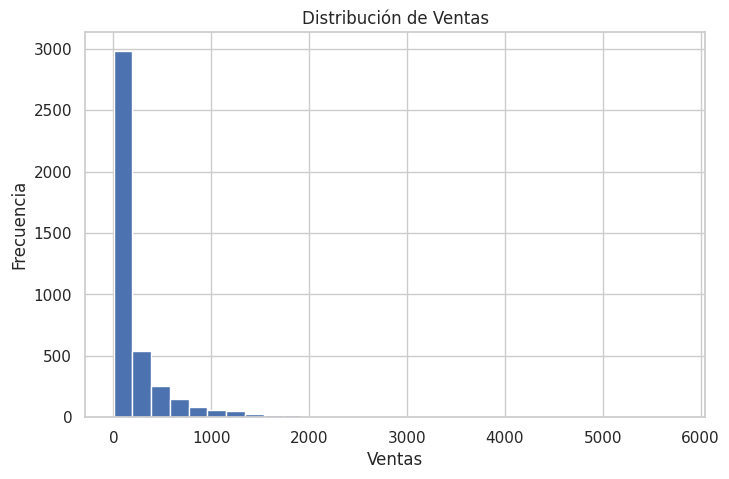

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Distribución de Ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")

plt.show()

#### Conclusión
La mayoría de las ventas se concentran en valores bajos y medios, mientras que existen pocas ventas de gran magnitud.

### 7. Boxplot de Beneficios por Categoría

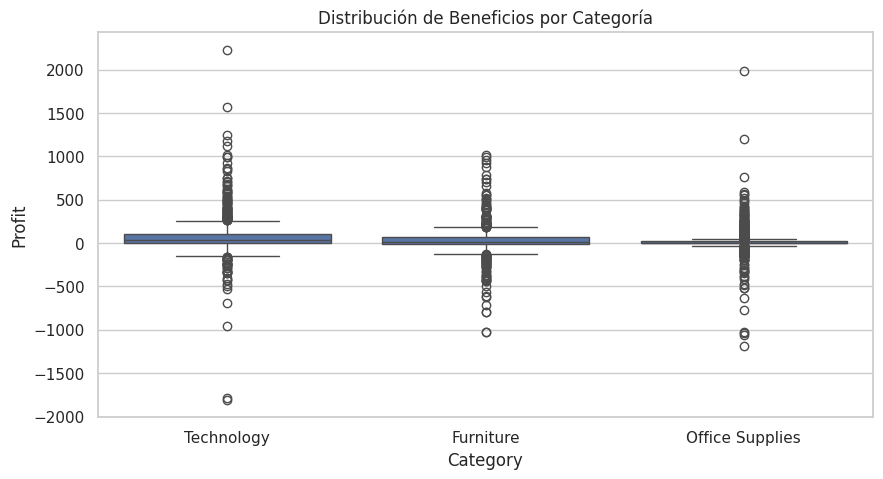

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Distribución de Beneficios por Categoría")

plt.show()

#### Conclusión

Se observan diferencias en la distribución de beneficios entre categorías y la presencia de valores atípicos.

### 8. Gráfico de Dispersión

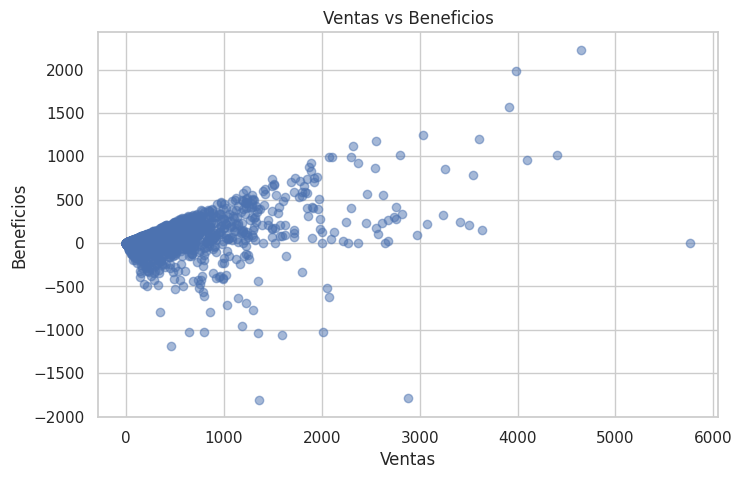

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.5
)

plt.title("Ventas vs Beneficios")
plt.xlabel("Ventas")
plt.ylabel("Beneficios")

plt.show()

#### Conclusión
Existe una tendencia positiva: conforme aumentan las ventas, generalmente aumentan los beneficios.

### 9. Gráfico de Regresión Lineal

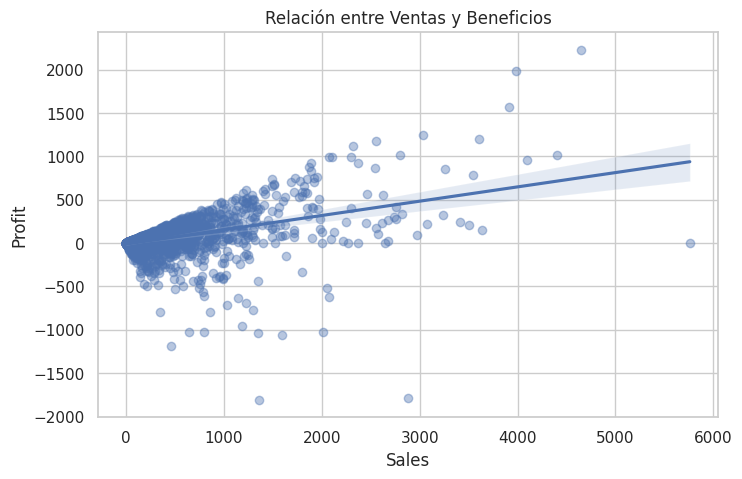

In [28]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Sales",
    y="Profit",
    scatter_kws={"alpha":0.4}
)

plt.title("Relación entre Ventas y Beneficios")

plt.show()

#### Conclusión
La línea de regresión confirma una correlación posiiva entre ventas y beneficios.

### 10. Gráfico Mapa de Calor

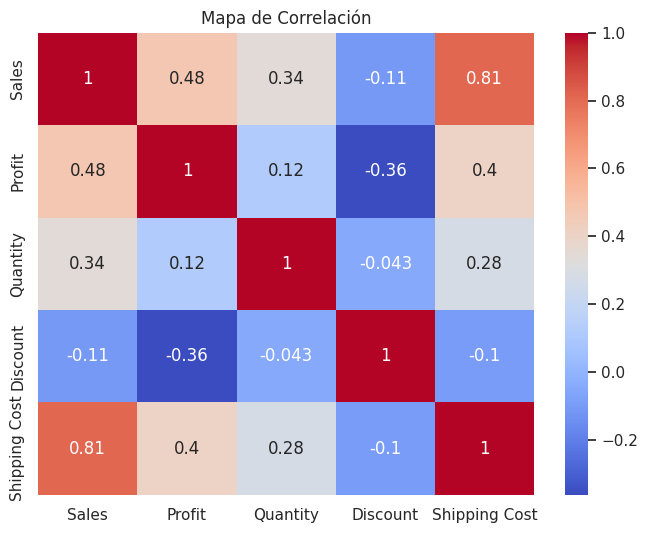

In [29]:
variables = df[
    [
        "Sales",
        "Profit",
        "Quantity",
        "Discount",
        "Shipping Cost"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    variables.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Mapa de Correlación")

plt.show()

#### Conclusión
El mapa de correlación muestra una relación positiva entre las ventas (Sales) y los beneficios (Profit). También se observa que algunas variables presentan correlaciones débiles, lo que sugiere que no todas influyen de manera significativa entre sí. Esta visualización facilita la identificación de patrones y relaciones dentro del conjunto de datos.

### 11. Subplots

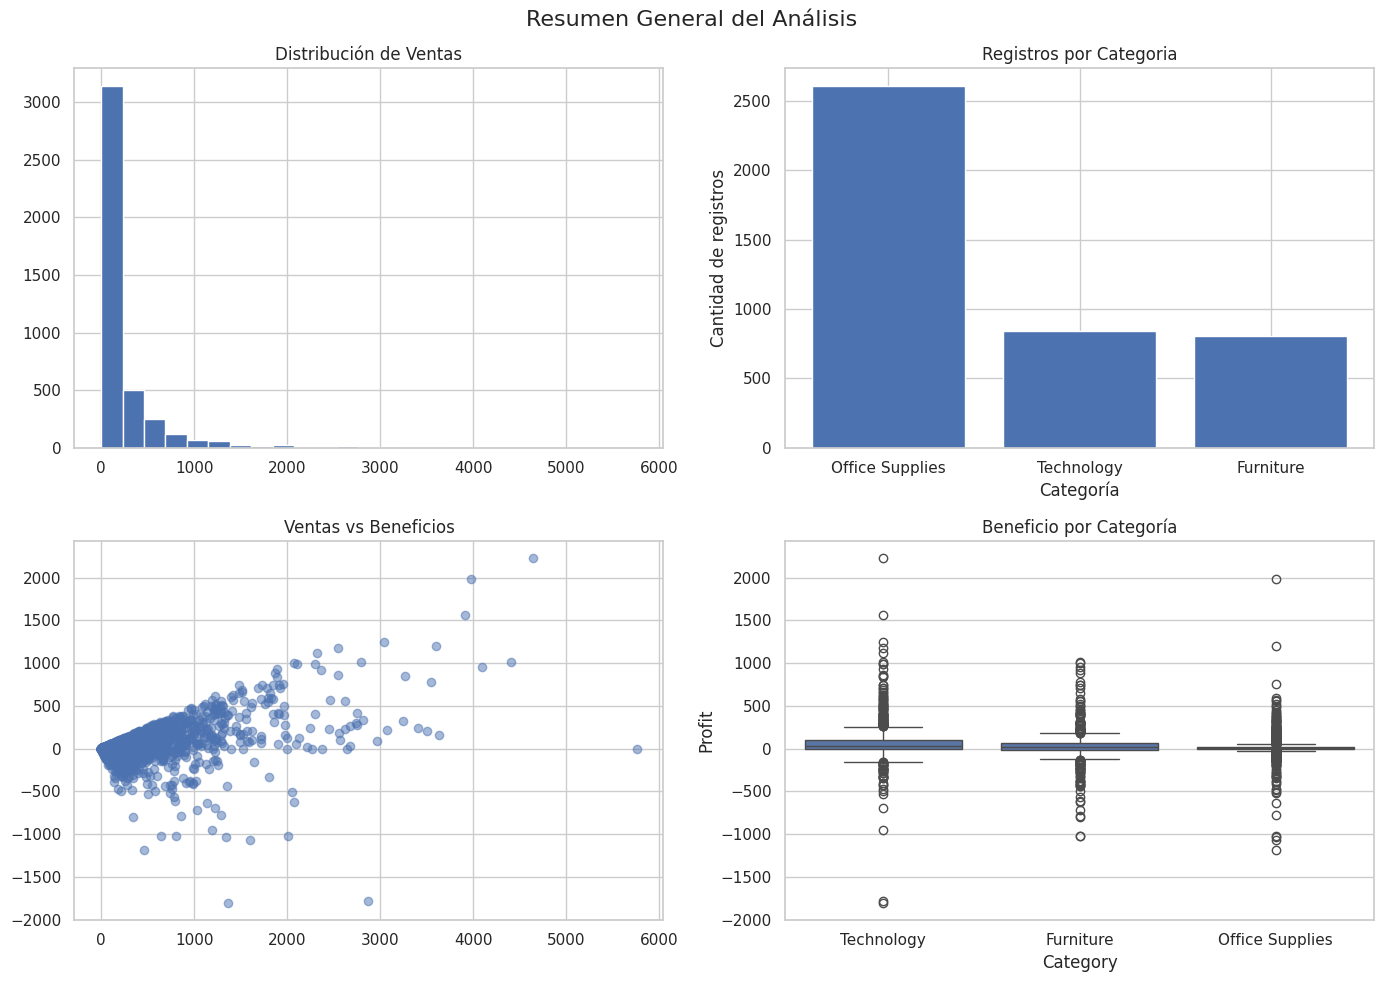

In [30]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# Histograma
axs[0,0].hist(df["Sales"], bins=25)
axs[0,0].set_title("Distribución de Ventas")

# Barras
categoria = df["Category"].value_counts()

axs[0,1].bar(
    categoria.index,
    categoria.values
)

axs[0,1].set_title("Registros por Categoria")
axs[0,1].set_xlabel("Categoría")
axs[0,1].set_ylabel("Cantidad de registros")

# Dispersión
axs[1,0].scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.5
)

axs[1,0].set_title("Ventas vs Beneficios")

# Boxplot
sns.boxplot(
    data=df,
    x="Category",
    y="Profit",
    ax=axs[1,1]
)

axs[1,1].set_title("Beneficio por Categoría")

fig.suptitle(
    "Resumen General del Análisis",
    fontsize=16
)

plt.tight_layout()

plt.show()

### 12. Guardar una Imagen

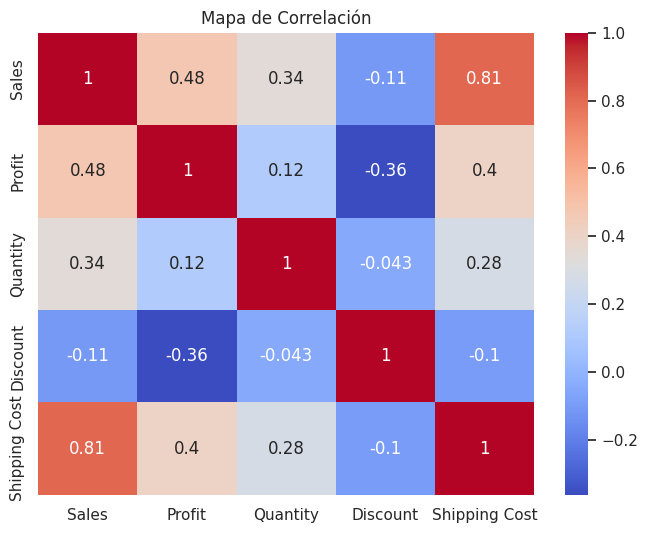

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    variables.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Mapa de Correlación")

plt.savefig(
    "heatmap_correlacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusiones Generales

- Las ventas presentan una distribución desigual, concentrándose principalmente en montos bajos y medios.
- Existe una relación positiva entre las ventas y los beneficios, aunque algunos pedidos generan pérdidas importantes.
- La categoría Technology tiende a registrar beneficios más altos, mientras que Furniture presenta una mayor variabilidad y pérdidas más significativas.
- El análisis de correlación permitió identificar relaciones entre las variables numéricas y comprender mejor el comportamiento de las ventas.
- Las visualizaciones facilitaron la identificación de patrones, valores atípicos y oportunidades de análisis para la toma de decisiones.